In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [57]:
Google_Data = pd.read_csv('./data/Google_Stock_Price.csv')
Google_Data

,timestamp,open,high,low,close,volume
0,2004-08-19,100.01,104.06,95.96,100.335,44659000
1,2004-08-20,101.01,109.08,100.50,108.310,22834300
2,2004-08-23,110.76,113.48,109.05,109.400,18256100
3,2004-08-24,111.24,111.60,103.57,104.870,15247300
4,2004-08-25,104.76,108.00,103.88,106.000,9188600
...,...,...,...,...,...,...
4996,2024-06-26,182.63,184.51,182.48,183.880,19838972
4997,2024-06-27,184.18,186.05,184.02,185.410,18848884
4998,2024-06-28,184.32,185.13,181.96,182.150,29156644
4999,2024-07-01,183.03,183.88,181.30,182.990,16006128


In [58]:
df = Google_Data
df

,timestamp,open,high,low,close,volume
0,2004-08-19,100.01,104.06,95.96,100.335,44659000
1,2004-08-20,101.01,109.08,100.50,108.310,22834300
2,2004-08-23,110.76,113.48,109.05,109.400,18256100
3,2004-08-24,111.24,111.60,103.57,104.870,15247300
4,2004-08-25,104.76,108.00,103.88,106.000,9188600
...,...,...,...,...,...,...
4996,2024-06-26,182.63,184.51,182.48,183.880,19838972
4997,2024-06-27,184.18,186.05,184.02,185.410,18848884
4998,2024-06-28,184.32,185.13,181.96,182.150,29156644
4999,2024-07-01,183.03,183.88,181.30,182.990,16006128


In [59]:
df.describe()

,open,high,low,close,volume
count,5001.000000,5001.000000,5001.000000,5001.000000,5.001000e+03
mean,791.497280,799.376622,783.214127,791.441941,8.797586e+06
std,613.276474,619.413907,606.722461,613.194639,1.104632e+07
min,85.400000,86.520000,83.340000,83.430000,3.845900e+04
25%,438.430000,445.000000,431.670000,437.920000,1.769069e+06
50%,596.140000,599.980000,591.670000,595.730000,4.229700e+06
75%,1032.040000,1043.980000,1020.450000,1032.640000,1.133440e+07
max,3025.000000,3030.931500,2977.980000,2996.770000,1.194550e+08


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  5001 non-null   object 
 1   open       5001 non-null   float64
 2   high       5001 non-null   float64
 3   low        5001 non-null   float64
 4   close      5001 non-null   float64
 5   volume     5001 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 234.6+ KB


In [61]:
df.isnull().sum()

timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

In [62]:
df.duplicated().sum()

0

In [63]:
# convert the timestamp to datetime dtype
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  5001 non-null   datetime64[ns]
 1   open       5001 non-null   float64       
 2   high       5001 non-null   float64       
 3   low        5001 non-null   float64       
 4   close      5001 non-null   float64       
 5   volume     5001 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 234.6 KB


In [64]:
# rename the timestamp to Date
df.rename(columns={'timestamp': 'Date'}, inplace=True)
df.set_index('Date', inplace=True)
df

,open,high,low,close,volume
Date,,,,,
2004-08-19,100.01,104.06,95.96,100.335,44659000
2004-08-20,101.01,109.08,100.50,108.310,22834300
2004-08-23,110.76,113.48,109.05,109.400,18256100
2004-08-24,111.24,111.60,103.57,104.870,15247300
2004-08-25,104.76,108.00,103.88,106.000,9188600
...,...,...,...,...,...
2024-06-26,182.63,184.51,182.48,183.880,19838972
2024-06-27,184.18,186.05,184.02,185.410,18848884
2024-06-28,184.32,185.13,181.96,182.150,29156644


In [65]:
# take data from 2015-01-01 to 20204-07-02
df = df.loc['2015-01-01':'2020-07-02']
df

,open,high,low,close,volume
Date,,,,,
2015-01-02,532.60,535.8000,527.88,529.55,1327870
2015-01-05,527.15,527.9899,517.75,519.46,2059119
2015-01-06,520.50,521.2100,505.55,506.64,2731813
2015-01-07,510.95,511.4900,503.65,505.15,2345875
2015-01-08,501.51,507.5000,495.02,506.91,3662224
...,...,...,...,...,...
2020-06-26,1432.63,1437.0200,1355.00,1362.54,4882014
2020-06-29,1360.34,1398.0000,1351.65,1397.17,2253678
2020-06-30,1396.88,1424.0000,1386.93,1418.05,2014320


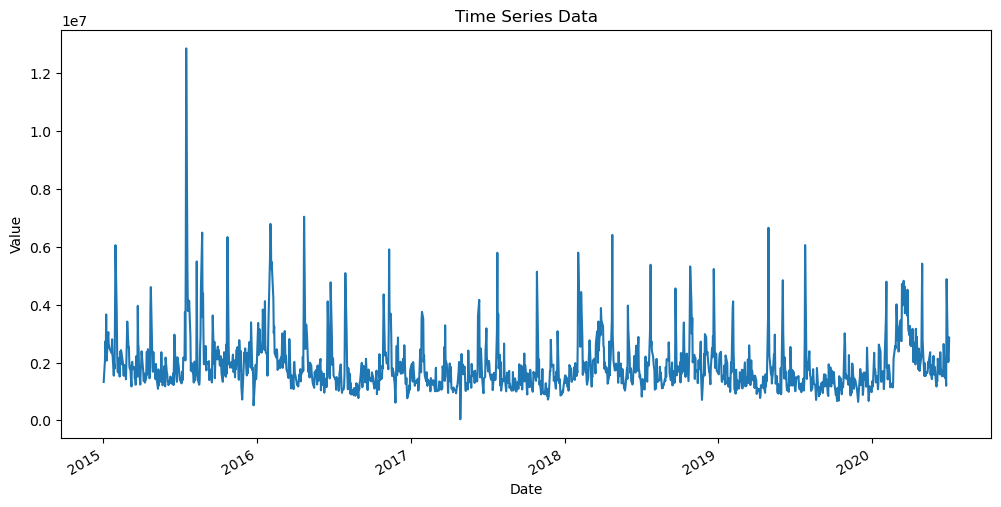

In [66]:
df['volume'].plot(figsize=(12, 6))
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()


In [67]:
# showing correlaiton
correlation = df.corr()
correlation

,open,high,low,close,volume
open,1.000000,0.999412,0.999229,0.998686,-0.113025
high,0.999412,1.000000,0.998971,0.999298,-0.101137
low,0.999229,0.998971,1.000000,0.999354,-0.129231
close,0.998686,0.999298,0.999354,1.000000,-0.116777
volume,-0.113025,-0.101137,-0.129231,-0.116777,1.000000


/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


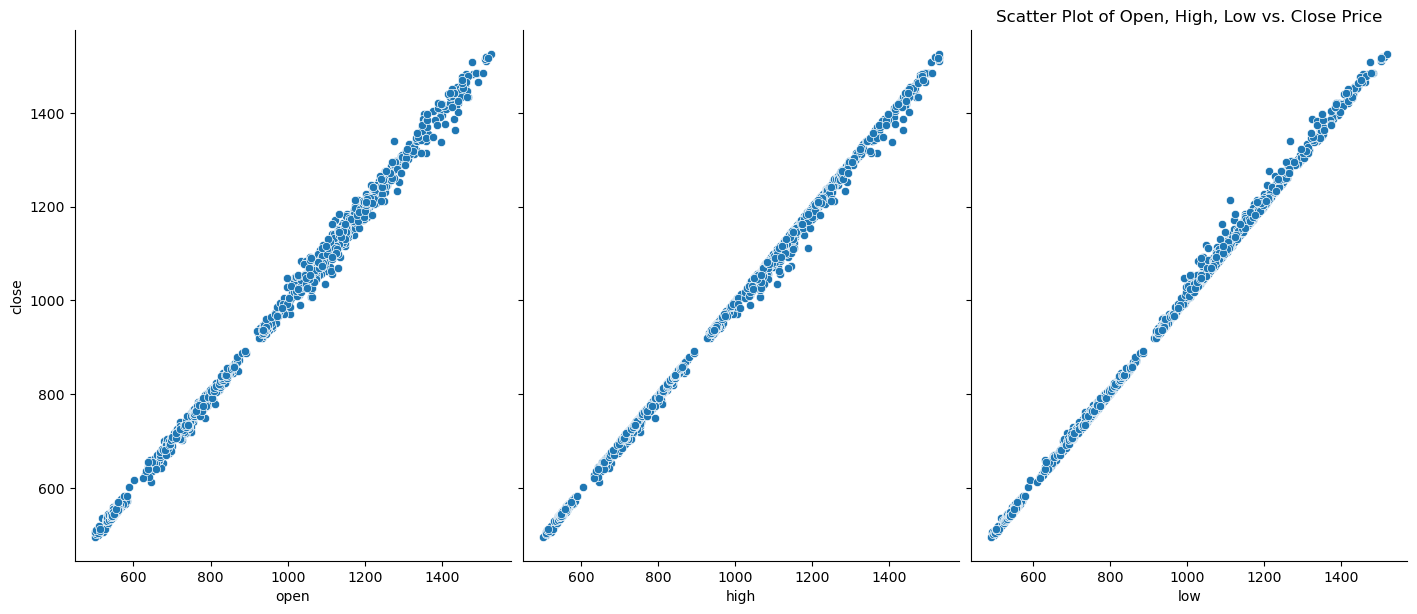

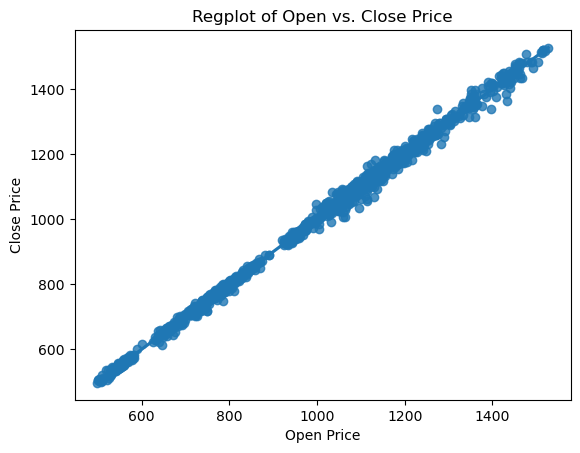

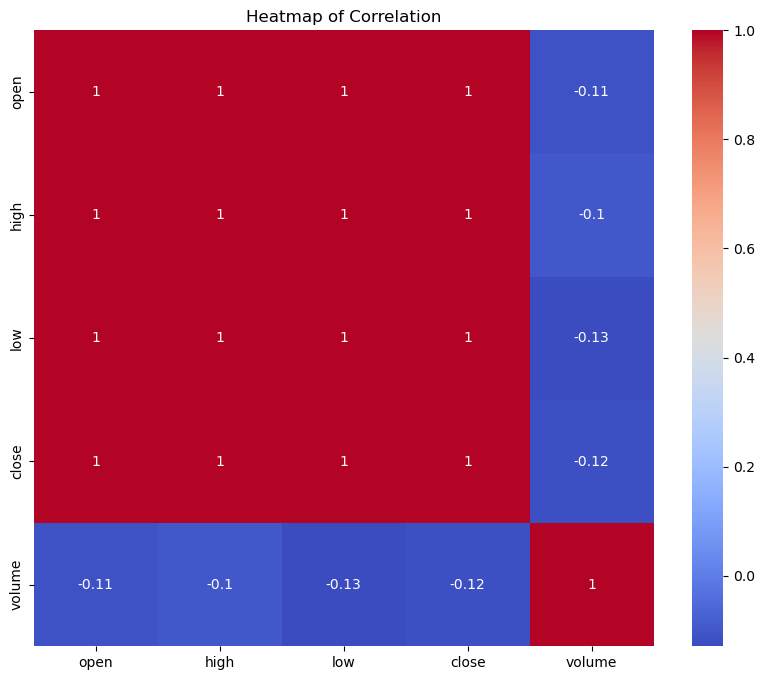

In [68]:
# Store the value of open, high, low in x variable, and close in y variable
x = df[['open', 'high', 'low']]
y = df['close']

# Scatter plot
sns.pairplot(df, x_vars=['open', 'high', 'low'], y_vars='close', height=6, aspect=0.8, kind='scatter')
plt.title('Scatter Plot of Open, High, Low vs. Close Price')
plt.show()

# Showing regplot for correlation between 'open' and 'close'
sns.regplot(x=df['open'], y=y)
plt.title('Regplot of Open vs. Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

# Showing correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlation')
plt.show()

In [69]:
window = 30
df['rolling_mean'] = df['volume'].rolling(window=window).mean()

/var/folders/1t/2c88cpvx50s6j4zn29nz2y580000gn/T/ipykernel_6236/458618357.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_mean'] = df['volume'].rolling(window=window).mean()


In [70]:
df

,open,high,low,close,volume,rolling_mean
Date,,,,,,
2015-01-02,532.60,535.8000,527.88,529.55,1327870,NaN
2015-01-05,527.15,527.9899,517.75,519.46,2059119,NaN
2015-01-06,520.50,521.2100,505.55,506.64,2731813,NaN
2015-01-07,510.95,511.4900,503.65,505.15,2345875,NaN
2015-01-08,501.51,507.5000,495.02,506.91,3662224,NaN
...,...,...,...,...,...,...
2020-06-26,1432.63,1437.0200,1355.00,1362.54,4882014,1.825486e+06
2020-06-29,1360.34,1398.0000,1351.65,1397.17,2253678,1.831369e+06
2020-06-30,1396.88,1424.0000,1386.93,1418.05,2014320,1.819965e+06


In [71]:
df.isnull().sum()

open             0
high             0
low              0
close            0
volume           0
rolling_mean    29
dtype: int64

In [72]:
# fill the NaN with the median
df['rolling_mean'].fillna(df['rolling_mean'].median(), inplace=True)

/var/folders/1t/2c88cpvx50s6j4zn29nz2y580000gn/T/ipykernel_6236/2028552902.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_mean'].fillna(df['rolling_mean'].median(), inplace=True)


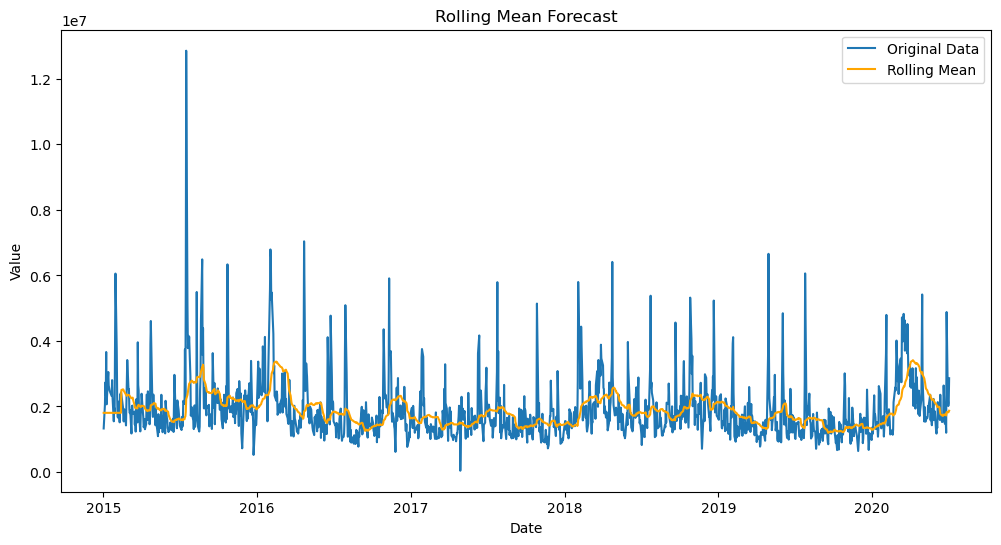

In [73]:
# Plot the rolling mean
plt.figure(figsize=(12, 6))
plt.plot(df['volume'], label='Original Data')
plt.plot(df['rolling_mean'], label='Rolling Mean', color='orange')
plt.title('Rolling Mean Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()